In [2409]:
import pandas
import copy
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import seaborn as sbn
import sys
import matplotlib.pyplot as plt


# show all elements of a dataframe
# pandas.set_option("display.max_rows", None)
pandas.set_option("display.max_columns", None)


sys.path.append("../src/")

In [2410]:
races = pd.read_csv('../dm-2024-project/dataset/preprocessedRaces.csv', sep=",")
races.head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,100.0,196000,5575,5.0,821,NaN,1,0,0,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,120.0,128000,781,1.0,1699,NaN,1,0,0,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,NaN,8100,68,NaN,804,NaN,1,0,0,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,2022-07-10,0.019404,1376.0,675.354230


In [2411]:
races.isna().sum()

_url                      0
name                      0
points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
date                      0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [2412]:
races.dtypes

_url                    object
name                    object
points                   int64
uci_points             float64
length                   int64
climb_total              int64
profile                float64
startlist_quality        int64
average_temperature    float64
is_tarmac                int64
is_cobbled               int64
is_gravel                int64
date                    object
climb/length           float64
median_delta           float64
std_delta              float64
dtype: object

In [2413]:
cyclists = pd.read_csv('../dm-2024-project/dataset/preprocessedCyclists.csv', sep=",")
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,sean-kelly,23.770000,6,16,629,Ireland,Europe,Northern Europe,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,gerrie-knetemann,19.777418,38,48,271,Netherlands,Europe,Western Europe,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,joseph-bruyere,20.313989,8,16,48,Belgium,Europe,Western Europe,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978


In [2414]:
cyclists.isna().sum()

name                        0
BMI                         0
median position             0
AVG position                0
# cyclist races             0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
AVG weighted position       0
AVG position Autumn      2879
AVG position Spring       737
AVG position Summer      1945
AVG position Winter      4523
AVG position Q1          1694
AVG position Q2          1023
AVG position Q3          2280
AVG position Q4          4270
std_dev position            0
dtype: int64

In [2415]:
cyclists.dtypes

name                      object
BMI                      float64
median position            int64
AVG position               int64
# cyclist races            int64
nationality               object
continent                 object
geo area                  object
birth_year               float64
AVG weighted position      int64
AVG position Autumn      float64
AVG position Spring      float64
AVG position Summer      float64
AVG position Winter      float64
AVG position Q1          float64
AVG position Q2          float64
AVG position Q3          float64
AVG position Q4          float64
std_dev position         float64
dtype: object

In [2416]:
placements = pd.read_csv('../dm-2024-project/dataset/preprocessedPlacements.csv', sep=",")
placements.head()

,position,cyclist,cyclist_age,cyclist_team,delta,date,_url,year
0,0,georges-pintens,24,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,norway-1987,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,spain-1991,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,spain-1991,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,NaN,33,1970-04-25,amstel-gold-race/1970/result,1970


In [2417]:
placements.isna().sum()

position             0
cyclist              0
cyclist_age          0
cyclist_team    159161
delta                0
date                 0
_url                 0
year                 0
dtype: int64

In [2418]:
placements.dtypes

position         int64
cyclist         object
cyclist_age      int64
cyclist_team    object
delta            int64
date            object
_url            object
year             int64
dtype: object

# Clustering for cyclists

## Data normalization

In [2419]:
numerical_cols = cyclists.select_dtypes(include=['float64', 'int64', 'Int64']).columns
numeric_cyclists_df = cyclists[numerical_cols]
numeric_cyclists_df


,BMI,median position,AVG position,# cyclist races,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,23.770000,6,16,629,1956.0,22,11.0,7.0,22.0,20.0,8.0,10.0,23.0,18.0,24.497844
1,19.777418,38,48,271,1951.0,66,56.0,15.0,58.0,NaN,15.0,18.0,66.0,NaN,46.993017
2,22.790000,42,47,146,1954.0,54,15.0,31.0,55.0,NaN,17.0,37.0,56.0,18.0,32.648452
3,20.313989,8,16,48,1948.0,21,29.0,11.0,19.0,NaN,5.0,14.0,23.0,NaN,19.723611
4,21.300000,25,33,145,1951.0,38,17.0,12.0,38.0,NaN,14.0,27.0,37.0,16.0,26.276978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6090,21.564270,173,173,1,1969.0,173,NaN,173.0,NaN,NaN,173.0,NaN,NaN,NaN,0.000000
6091,22.244361,17,17,1,1965.0,17,NaN,17.0,NaN,NaN,17.0,NaN,NaN,NaN,0.000000
6092,25.450000,54,54,1,1992.0,54,NaN,NaN,54.0,NaN,NaN,NaN,54.0,NaN,0.000000
6093,19.965263,38,38,1,1948.0,38,NaN,38.0,NaN,NaN,38.0,NaN,NaN,NaN,0.000000


Feature selection based on NAN values and high correlation

In [2420]:
numeric_cyclists_df = numeric_cyclists_df[['BMI', 'median position', '# cyclist races', 'birth_year', 'std_dev position']]
numeric_cyclists_df

,BMI,median position,# cyclist races,birth_year,std_dev position
0,23.770000,6,629,1956.0,24.497844
1,19.777418,38,271,1951.0,46.993017
2,22.790000,42,146,1954.0,32.648452
3,20.313989,8,48,1948.0,19.723611
4,21.300000,25,145,1951.0,26.276978
...,...,...,...,...,...
6090,21.564270,173,1,1969.0,0.000000
6091,22.244361,17,1,1965.0,0.000000
6092,25.450000,54,1,1992.0,0.000000
6093,19.965263,38,1,1948.0,0.000000


,BMI,median position,# cyclist races,birth_year,std_dev position
BMI,1.000000,0.008012,-0.030030,-0.129670,0.026745
median position,0.008012,1.000000,-0.080105,0.486306,0.258890
# cyclist races,-0.030030,-0.080105,1.000000,0.161916,0.356324
birth_year,-0.129670,0.486306,0.161916,1.000000,0.248989
std_dev position,0.026745,0.258890,0.356324,0.248989,1.000000


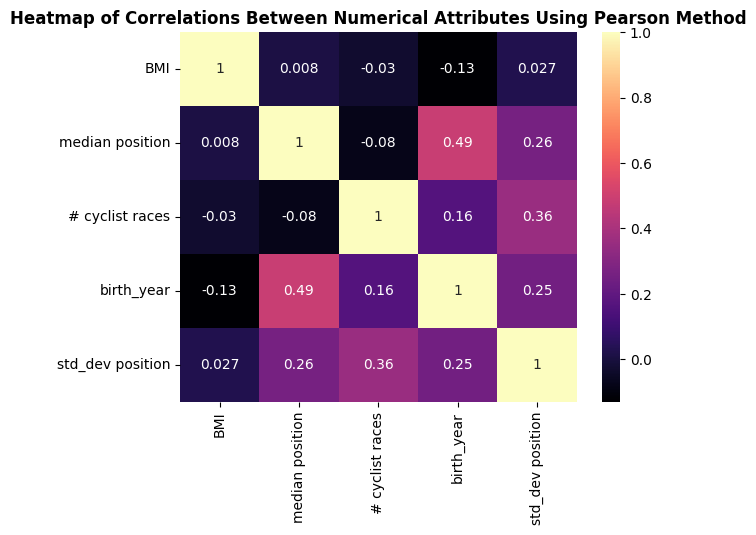

In [2421]:
pearson_matrix = numeric_cyclists_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

In [2422]:
from sklearn.preprocessing import StandardScaler

def standardize_fun(df):
    scaler = StandardScaler()
    scaler.fit(df)
    X = scaler.transform(df)
    standardized_df = pd.DataFrame(X, columns=df.columns, index=df.index)
    print(standardized_df)
    
    standardizer = {"scaler": scaler, "standardized_df": standardized_df}

    return standardizer
   


In [2423]:
standardizer = standardize_fun(numeric_cyclists_df)
standardized_cyclists_df = standardizer['standardized_df']

           BMI  median position  # cyclist races  birth_year  std_dev position
0     1.888908        -1.858581         3.780169   -1.159440         -0.480565
1    -1.057115        -1.009907         1.237430   -1.481151          0.791989
2     1.165791        -0.903823         0.349602   -1.288124         -0.019484
3    -0.661193        -1.805539        -0.346455   -1.674178         -0.750644
4     0.066359        -1.354681         0.342499   -1.481151         -0.379919
...        ...              ...              ...         ...               ...
6090  0.261357         2.570438        -0.680279   -0.322989         -1.866411
6091  0.763178        -1.566850        -0.680279   -0.580358         -1.866411
6092  3.128536        -0.585570        -0.680279    1.156885         -1.866411
6093 -0.918509        -1.009907        -0.680279   -1.674178         -1.866411
6094 -0.631507        -0.399922        -0.680279   -1.416809         -1.866411

[6095 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_cyclists_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced space

In [2424]:
# Try to apply PCA to get the optimal number of components
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_cyclists = pca_instance.fit_transform(standardized_cyclists_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 4


In [2425]:
# pca = PCA()
# pca.fit(X) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_cyclists_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


In [2426]:
pca_std_numeric_cyclists

array([[-0.86707179,  3.99982827,  0.99575881, -2.03941438],
       [-0.49945573,  1.98239433, -1.05913895,  0.95176429],
       [-1.234729  ,  1.16092015,  1.02527739,  0.09231052],
       ...,
       [-1.09092846, -0.87908639,  2.48933566, -2.49345297],
       [-2.61868305, -0.34207412, -1.1131275 ,  0.00626361],
       [-2.17431663, -0.6859227 , -0.74680945, -0.13070555]])

## Kmeans greedy search

In [2427]:
def kmeans_greedy_search(df):
    results = []  # used to save sse and silhouette for each k
    previous_sse = None

    for k in range(2,16):
        kmeans = KMeans(n_clusters=k, max_iter=300, random_state=42)
        labels = kmeans.fit_predict(df)
        sse = kmeans.inertia_  # Calcola il SSE
        silhouette_avg = silhouette_score(df, labels) 

        if previous_sse is not None:
            sse_reduction_percentage = ((previous_sse - sse) / previous_sse) * 100
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}, sse reduction: {sse_reduction_percentage:.2f}%")
        else:
            print(f"k: {k} -> silhouette: {silhouette_avg}, sse: {sse}")
    
        # Salva i risultati
        results.append({"k": k, "sse": sse, "silhouette": silhouette_avg})
        previous_sse = sse
   
    return results

In [2428]:
def k_means_evaluation_plotting(results):

    print(results)
    k_values = [result["k"] for result in results]
    sse_values = [result["sse"] for result in results]
    silhouette_values = [result["silhouette"] for result in results]

    plt.figure()
    plt.plot(k_values, sse_values, marker='o', label='SSE')
    plt.title('SSE with Elbow method')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('SSE')
    plt.show()

    plt.figure()
    plt.plot(k_values, silhouette_values, marker='o', label='Silhouette Score', color='orange')
    plt.title('Silhouette Score')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.show()

In [2429]:
def get_best_k(results):
    best_result = max(results, key=lambda x: x["silhouette"])

    best_k = best_result["k"]
    return best_k

In [2430]:
# # Configurazione dei parametri per il Grid Search
# k_values = range(2, 11)
# param_grid = {
#     'n_clusters': k_values,
# }

# # Creazione del modello KMeans
# kmeans = KMeans(random_state=42)

# # Variabili per tracciare i migliori risultati
# best_combined_score = -float('inf')
# best_combined_params = {}

# # Liste per normalizzazione
# sse_all = []
# silhouette_all = []
# separation_all = []
# param_list = []

# # Itera sui parametri
# for n_clusters in param_grid['n_clusters']:

#     kmeans = KMeans(n_clusters=n_clusters, random_state=42, init='k-means++', max_iter=300)
    
#     labels = kmeans.fit_predict(X)
#     silhouette = silhouette_score(X, labels)
#     sse = kmeans.inertia_
#     separation = davies_bouldin_score(X, labels)

#     # Aggiungi ai valori globali per normalizzare successivamente
#     sse_all.append(sse)
#     silhouette_all.append(silhouette)
#     separation_all.append(separation)
#     param_list.append({'n_clusters': n_clusters, 'max_iter': 300})  # Salva i parametri associati

#     print(f"n_clusters: {n_clusters}, max_iter: {300} -> SSE: {sse}, Davies-Bouldin: {separation}, Silhouette: {silhouette}")

# # Normalizza le metriche
# sse_min, sse_max = min(sse_all), max(sse_all)
# silhouette_min, silhouette_max = min(silhouette_all), max(silhouette_all)
# separation_min, separation_max = min(separation_all), max(separation_all)

# sse_norm = [(sse_max - sse) / (sse_max - sse_min) for sse in sse_all]
# silhouette_norm = [(silhouette - silhouette_min) / (silhouette_max - silhouette_min) for silhouette in silhouette_all]
# separation_norm = [(separation_max - sep) / (separation_max - separation_min) for sep in separation_all]

# # Ricalcola il punteggio combinato
# for i, (sse, silhouette, separation) in enumerate(zip(sse_norm, silhouette_norm, separation_norm)):
#     combined_score = (silhouette + sse + separation) / 3  # Media pesata
#     if combined_score > best_combined_score:
#         best_combined_score = combined_score
#         best_combined_params = {'n_clusters': param_list[i]['n_clusters'],
#             'max_iter': param_list[i]['max_iter'],'index': i, 'sse': sse, 'silhouette': silhouette, 'separation': separation}

# # Risultati
# print("\nMiglior punteggio combinato:", best_combined_score)
# print("Parametri associati:", best_combined_params)

In [2431]:
# # Crea il grafico della distribuzione dei punti nei cluster (scatter plot)
# plt.figure(figsize=(10, 6))
# sbn.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="Set2", s=50, alpha=0.7)
# plt.title(f'Cluster con {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Feature 1', fontsize=12)
# plt.ylabel('Feature 2', fontsize=12)
# plt.show()

# # Calcola la silhouette score per ogni punto
# silhouette_vals = silhouette_samples(X, labels)

# # Crea un grafico della silhouette score per ogni punto
# plt.figure(figsize=(10, 6))
# sbn.histplot(silhouette_vals, kde=True, color="skyblue", bins=50)
# plt.title(f'Punteggio Silhouette per {best_params["n_clusters"]} cluster', fontsize=14)
# plt.xlabel('Silhouette Score', fontsize=12)
# plt.ylabel('Frequenza', fontsize=12)
# plt.show()

In [2432]:
results = kmeans_greedy_search(pca_std_numeric_cyclists)

k: 2 -> silhouette: 0.28153043863911553, sse: 20264.583424216784
k: 3 -> silhouette: 0.28131764493363426, sse: 15968.7183538791, sse reduction: 21.20%
k: 4 -> silhouette: 0.2570379027112465, sse: 13374.654822551942, sse reduction: 16.24%
k: 5 -> silhouette: 0.25156782541416184, sse: 11772.809105521294, sse reduction: 11.98%
k: 6 -> silhouette: 0.2492270952482649, sse: 10403.92652094231, sse reduction: 11.63%
k: 7 -> silhouette: 0.24328902949389675, sse: 9601.698510973023, sse reduction: 7.71%
k: 8 -> silhouette: 0.23110928941116796, sse: 8931.946230811307, sse reduction: 6.98%
k: 9 -> silhouette: 0.2228574285605877, sse: 8410.067011164185, sse reduction: 5.84%
k: 10 -> silhouette: 0.21570306538337303, sse: 8067.8263665671975, sse reduction: 4.07%
k: 11 -> silhouette: 0.2148520890065374, sse: 7698.266922274126, sse reduction: 4.58%
k: 12 -> silhouette: 0.2145785628062774, sse: 7268.634320038195, sse reduction: 5.58%
k: 13 -> silhouette: 0.2138245408895134, sse: 6877.738918051752, sse re

[{'k': 2, 'sse': 20264.583424216784, 'silhouette': np.float64(0.28153043863911553)}, {'k': 3, 'sse': 15968.7183538791, 'silhouette': np.float64(0.28131764493363426)}, {'k': 4, 'sse': 13374.654822551942, 'silhouette': np.float64(0.2570379027112465)}, {'k': 5, 'sse': 11772.809105521294, 'silhouette': np.float64(0.25156782541416184)}, {'k': 6, 'sse': 10403.92652094231, 'silhouette': np.float64(0.2492270952482649)}, {'k': 7, 'sse': 9601.698510973023, 'silhouette': np.float64(0.24328902949389675)}, {'k': 8, 'sse': 8931.946230811307, 'silhouette': np.float64(0.23110928941116796)}, {'k': 9, 'sse': 8410.067011164185, 'silhouette': np.float64(0.2228574285605877)}, {'k': 10, 'sse': 8067.8263665671975, 'silhouette': np.float64(0.21570306538337303)}, {'k': 11, 'sse': 7698.266922274126, 'silhouette': np.float64(0.2148520890065374)}, {'k': 12, 'sse': 7268.634320038195, 'silhouette': np.float64(0.2145785628062774)}, {'k': 13, 'sse': 6877.738918051752, 'silhouette': np.float64(0.2138245408895134)}, {'

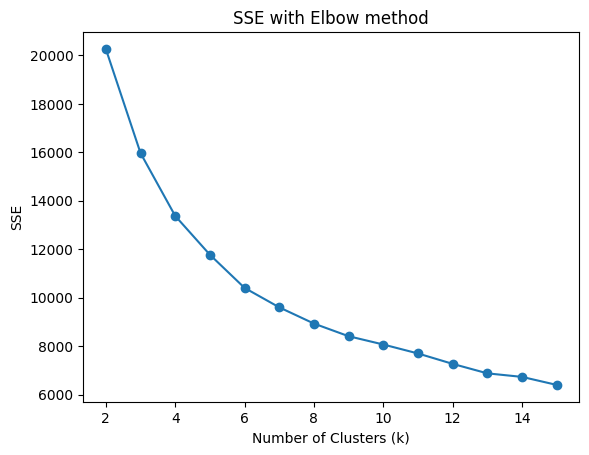

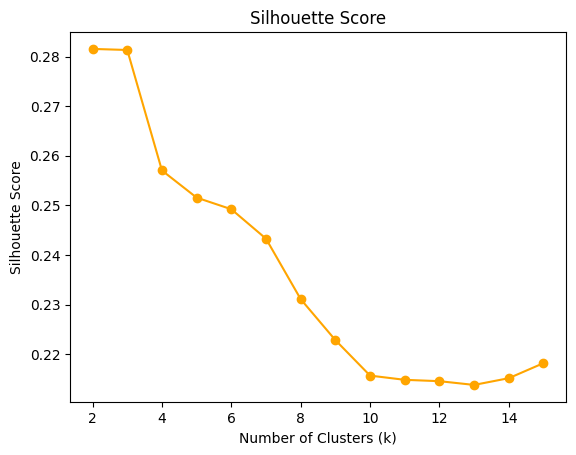

In [2433]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 2  as the optimal number of clusters, while the SSE indicates  k = 5  or  k = 6 . As a trade-off, we choose  k = 4 .

In [2434]:
def kmeans_run(data, best_k, scaler):
    scaler = standardizer['scaler']
    print(f"\nBest k based on a trade-off between silhuoette score and sse: {best_k}")

    # best kmeans with best clusters number
    best_kmeans = KMeans(n_clusters=best_k, random_state=42, init='k-means++', max_iter=300)

    best_kmeans.fit(data)
    print(f"k: {best_k}, Number of iterations: {best_kmeans.n_iter_}")

    centers = best_kmeans.cluster_centers_

    # Trasforma i centroidi dallo spazio PCA a quello standardizzato
    centers_standardized = pca_instance.inverse_transform(centers)

    # Inverso della trasformazione per ottenere i centroidi nello spazio originale (non normalizzato)
    centers_original_space = scaler.inverse_transform(centers_standardized)

    print("Centroids")
    print(centers_original_space)

    kmeans_data = {"best_kmeans": best_kmeans, "centroids": centers_original_space}

    return kmeans_data

  



In [2435]:
kmeans_data = kmeans_run(data=pca_std_numeric_cyclists, best_k=4, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k based on a trade-off between silhuoette score and sse: 4
k: 4, Number of iterations: 17
Centroids
[[  22.05561454   91.58639313   84.616417   1972.35687433   46.21636565]
 [  20.46742596  102.30530632   44.67683321 1985.82769307   29.07177391]
 [  20.88762988   56.21260717  357.95867918 1981.84235352   43.86150367]
 [  21.34032052   35.53201514   20.56089352 1956.0685156    15.47681383]]


In [2436]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0    1798
1    1913
2     899
3    1485
Name: count, dtype: int64


Let's print a summary of the average values for each feature within the clusters

In [2437]:
numeric_cyclists_df = numeric_cyclists_df.copy() 
# Add Cluster as a column to the dataset
numeric_cyclists_df['Cluster'] = best_kmeans.labels_

cluster_stats = numeric_cyclists_df.groupby('Cluster').agg('mean')

display(cluster_stats)

,BMI,median position,# cyclist races,birth_year,std_dev position
Cluster,,,,,
0,22.064436,90.302002,81.229700,1972.941602,46.538538
1,20.471930,100.180345,39.514898,1986.476738,29.505318
2,20.853281,63.400445,375.703003,1979.293660,42.233948
3,21.342493,35.487542,20.515152,1956.085522,15.490449


## Distribution of points for each feature across clusters

In [2438]:
def clusters_box_plot(df):

    columns = [col for col in df.columns if col != 'Cluster']
    n_rows = (len(columns) + 2 - 1) // 2  

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows), sharey=False)

    # Rendi axes un array 1D per un accesso più semplice
    axes = axes.flatten()

    for i, column in enumerate(columns):
        sbn.boxplot(x='Cluster', y=column, data=df, ax=axes[i])
        axes[i].set_title(f"Distribution of '{column}'")
        axes[i].set_xlabel("Cluster")
        axes[i].set_ylabel(column)

    # Nascondi subplot extra (se presenti)
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

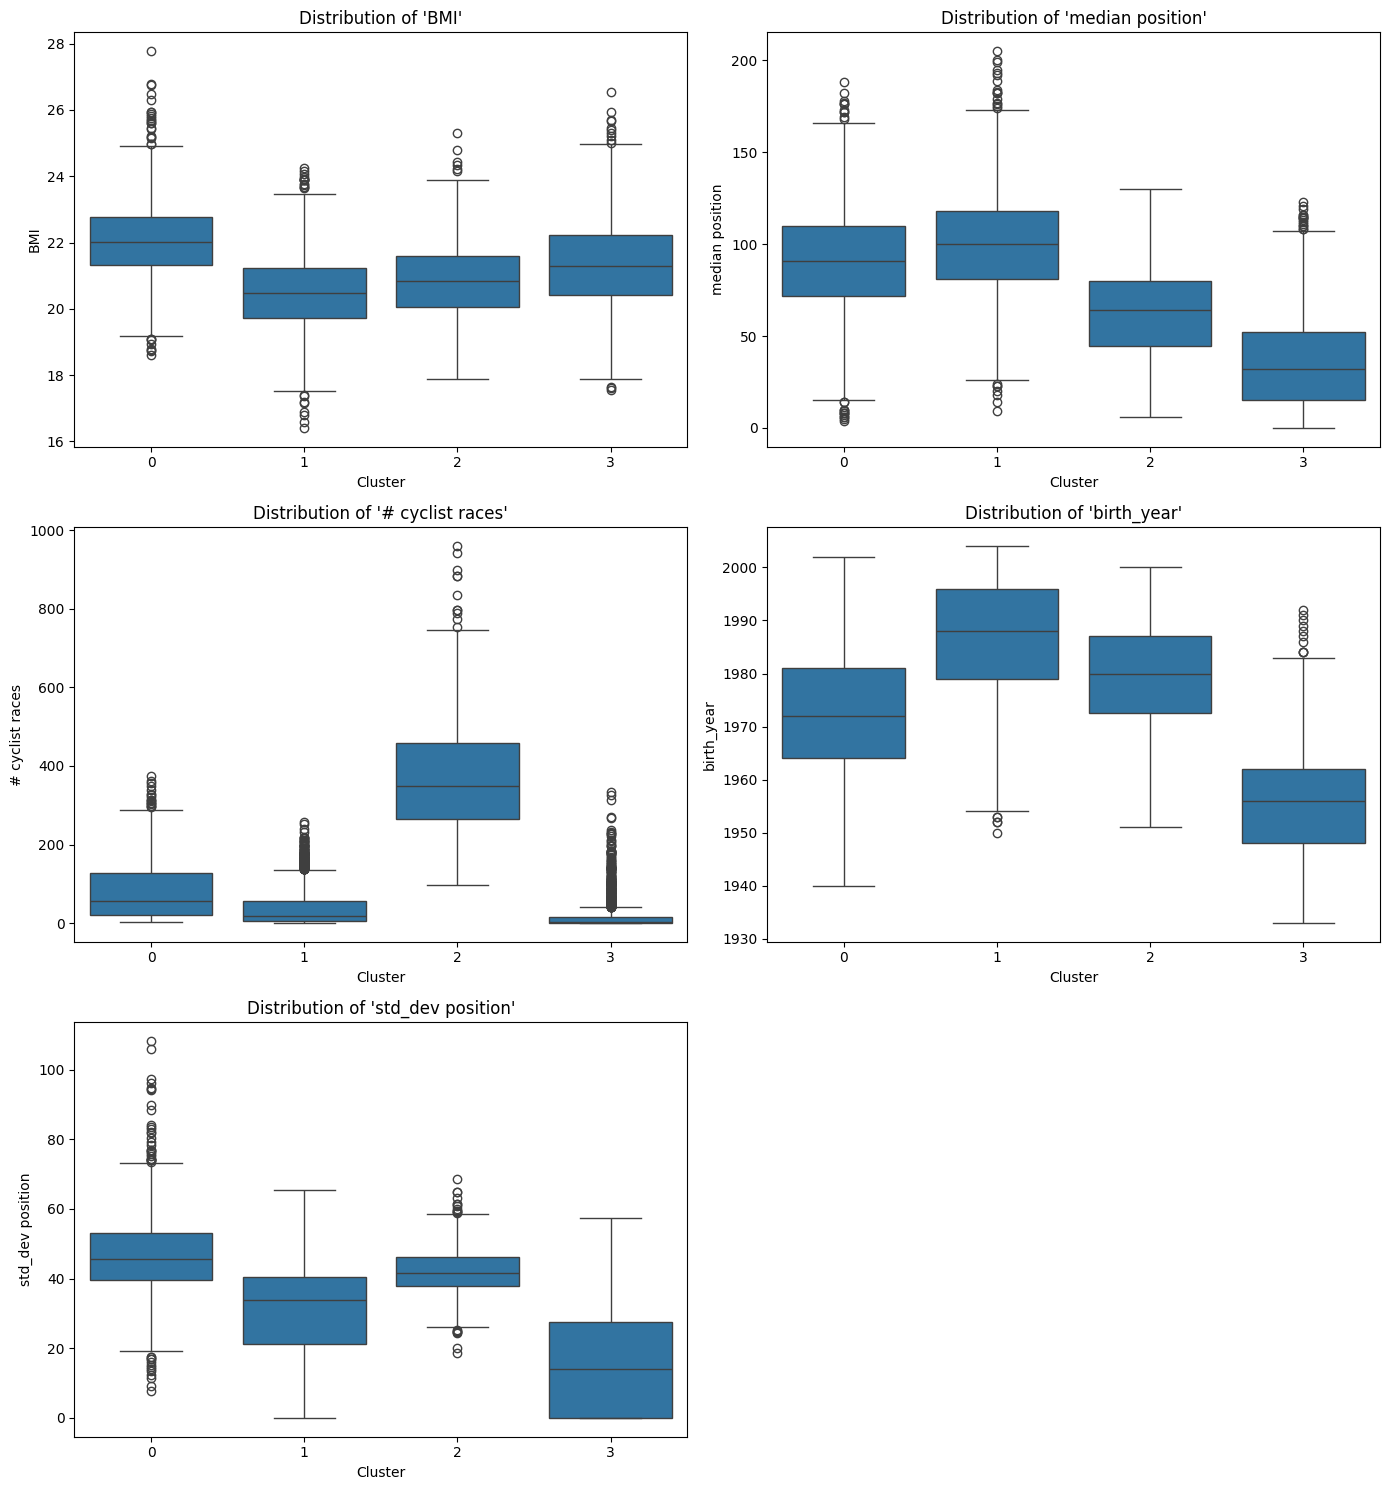

In [2439]:
clusters_box_plot(numeric_cyclists_df)

### Box-plots analysis

By analying the box-plots above, we can try to analyze the 4 clusters by considering points distribution for each feature:
- **Cluster 0**: 

  - **_BMI_**: values are centered around a median of 22, with a moderately tight interquartile range. There are some outliers on both the lower and upper ends, with the lowest BMI slightly below 18 and the highest around 28.
  
  - **_median position_**: this cluster has the widest IQR for the median position, with values ranging from ~20 to ~170. The median is approximately 80. There are many outliers: the gratest with ~200 and the lowest close to 0. 

  - **_cyclist races_**: cyclists in this cluster participated in not many races with a median below 100. There are some high-end outliers, with values over 300.
  
  - **_birth\_year_**: this cluster has a median birth year around 1970, with an IQR ranging from ~1965 to 1980. There are not outliers.

  - **_std\_dev position_**: the median standard deviation of position is around 42 and IQR ranges from 40 to ~58. This cluster has a lot of outliers on both the lower and the upper ends, from ~10 to above 100.

- **Cluster 1**: 

  - **_BMI_**: the median BMI is approximately 21, and outliers are present on both ends.
  
  - **_median position_**: the median position is higher than the ones in the Cluster 0 (~100). Similar to Cluster 0, there are many high-end outliers close to 200, and many low-end outliers close to 20.

  - **_cyclist races_**: the distribution shows a tighter IQR and a lower median, below 50. There are high-end outliers, with values up to ~300.
  
  - **_birth\_year_**: the median birth year is ~1990. Outliers are present in the ~1950s.

  - **_std\_dev position_**: the median std deviation of position is around 37 and the IQR ranges from ~20 to ~40. There are not outliers.

- **Cluster 2**: 

  - **_BMI_**: the median BMI is around 21, similar to the Cluster 1, but here we don't have low-end outliers. Some high-end outliers exceed up to about 25.
  
  - **_median position_**: this cluster has a smaller IQR compared to the others, with a median position around ~60. It doesn't contains outliers.

  - **_cyclist races_**: this cluster has the highest median ~380 and a wide IQR. It also contains a significant number of high-end outliers, up to about ~1000.
  
  - **_birth\_year_**: here IQR is tighter compared to the others, ranging from ~1972 to ~1985 and a median value of 1980. There are no outliers.

  - **_std\_dev position_**: median is about ~40 and IQR is relatively and IQR is the narrowest compared to all the other clusters. Outliers appear to be on both the lower and the upper ends.

- **Cluster 3**: 

  - **_BMI_**: median is about ~21 and the IQR is the slightly widest. There are few low-end outliers and many other high-end ones.
  
  - **_median position_**: the median position is the smallest here, about ~30, with some outliers on the upper end up to ~120.

  - **_cyclist races_**: cyclists in this cluster have the smallest number of races, with a median around ~10 and a tight IQR. There are a lot of outliers on the upper part, up to about ~380.
  
  - **_birth\_year_**: this cluster has the cyclists born in more distant years, with a median around 1955. Some outliers extend to earlier years, up to 1990s.

  - **_std\_dev position_**: this cluster has the smallest median standard deviation of position, ~18, but the widest IQR, ranging from ~0 to ~30, suggesting more consistency in performance. There are no outliers.




 

Based on the analysis provided, here’s what we can infer about the clusters:
#### Cluster 0
Cyclists appear to be a middle-ground group in many respects. They tend to have a BMI around 22, which is higher than most other clusters, possibly indicating a group with a more average or heavier build. Their birth years cluster around the 1970s, so these are likely middle-aged cyclists.

Their median race positions show the widest spread, ranging from poor to competitive positions, suggesting this cluster might include a mix of cyclists with varied abilities or those who perform differently depending on the type of race. While most cyclists in this cluster have participated in fewer than 100 races, there are a few individuals who are much more active, as indicated by the high-end outliers. This diversity suggests that Cluster 0 might represent a transitional group with both experienced veterans and less competitive cyclists.

#### Cluster 1
Cluster 1 is defined by younger cyclists, and they generally have participated in relatively few races (median ~50). This could represent a group of cyclists who are earlier in their careers, or perhaps participating in fewer high-level races.

Their median position is relative higher (~100), indicating that they tend to finish races further back in the rankings. There are several high-end outliers in terms of race participation, which might indicate a subset of very active cyclists in this group.

The standard deviation of their race positions is lower than Cluster 0, suggesting slightly more consistent results. Overall, Cluster 1 might represent young, developing cyclists, many of which are still finding their footing in the competitive field.

#### Cluster 2
Cluster 2 stands out as the most active and competitive group. These cyclists have participated in the highest number of races (median ~380). Their birth years suggest they are in their prime, with a median around 1980.

This cluster shows a median position of ~60, indicating solid but not dominant performance in races. Cluster 2 demonstrates consistency in cyclists performance due to several key factors. Their median position is tightly distributedand their standard deviation of position is relatively low (~40), showing minimal fluctuations in their race outcomes. Also the group has participated in a large number of races while maintaining stable performance, suggesting experience and refined racing strategies.

There are also a significant number of outliers for race participation, suggesting a subset of overachievers who have raced in extraordinarily high numbers of events.

Cluster 2 likely represents a group of elite cyclists who are both highly competitive and active.

#### Cluster 3
Cyclists have the lowest participation in races, with a median of only ~10, but they display a very tight distribution in their performance, as seen by the smallest standard deviation (~18). Their consistent results and relatively low median position (~30) suggest they are experienced cyclists who focus on select events and excel in those. 

But it must be underlined that having participated in few competitions, these data are a bit "falsified".

These cyclists are also much older than the other clusters, with a median birth year around 1955 and some born as early as the 1930s. This cluster might include retired professionals or cyclists who continue to compete in races.

Cluster 3 likely represents "veterans" who prioritize quality over quantity in their racing careers.

## Clusters visualization with feature distributions and centroids 

In [2440]:
    
def clusters_pairplot(df, kmeans_labels, centroids):
    df['Cluster'] = kmeans_labels

    pairplot = sbn.pairplot(
        df,
        hue='Cluster',
        palette='Set1',
        diag_kind='kde',
        markers='o',
        plot_kws={'alpha': 0.6}
    )

    for i, ax in enumerate(pairplot.axes.flat):
        # Get features for each subplot
        row_feature = pairplot.axes.flat[i].get_ylabel()
        col_feature = pairplot.axes.flat[i].get_xlabel()

        # Add centroids only to relevant scatter plots, excluding diagonal ones
        if row_feature in df.columns and col_feature in df.columns:
            ax.scatter(
                centroids[:, df.columns.get_loc(col_feature)],  
                centroids[:, df.columns.get_loc(row_feature)], 
                marker='x', s=100, c='black', label='Centroid'
            )

    plt.legend()
    plt.show()

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_89772/3208931329.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


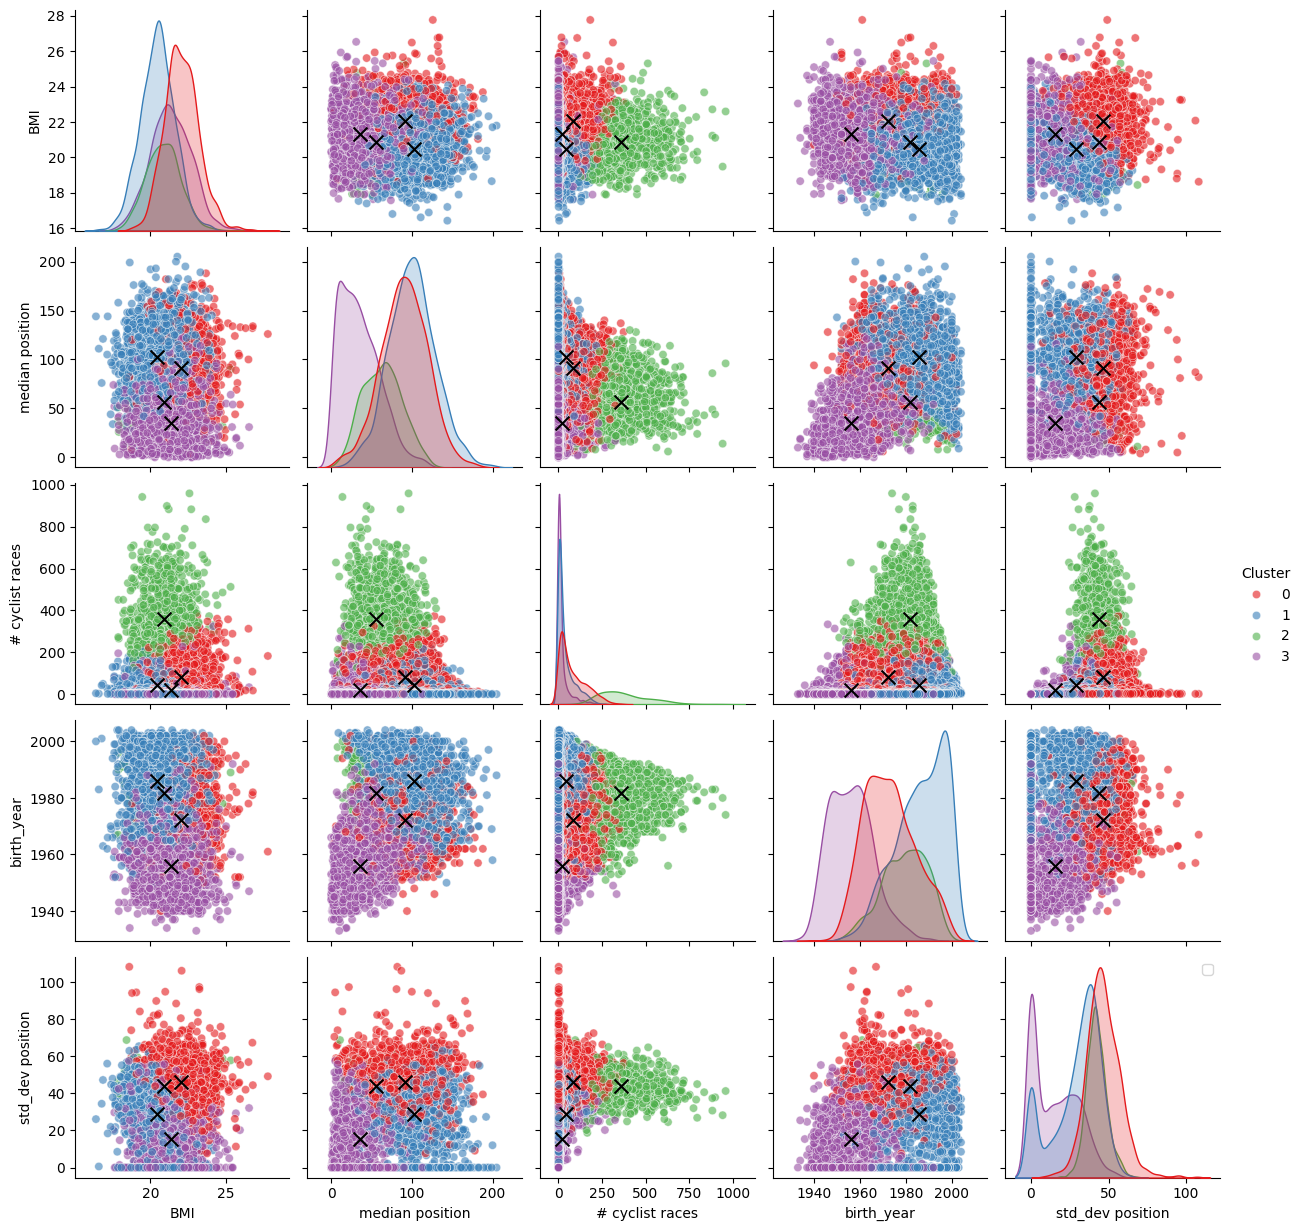

In [2441]:
clusters_pairplot(numeric_cyclists_df, best_kmeans.labels_, centroids)

## Geographic distribution of cyclists across clusters

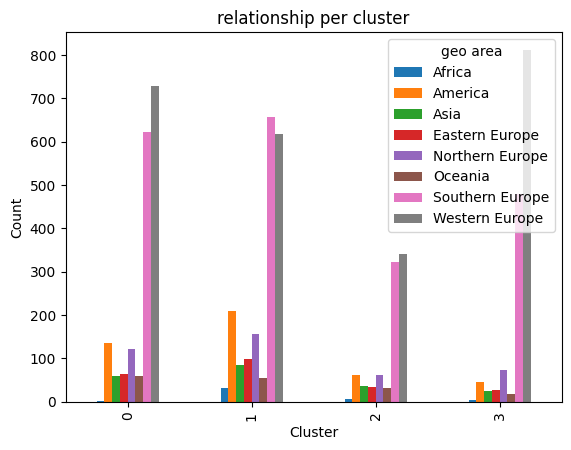

In [2442]:
cross_df = pandas.crosstab(best_kmeans.labels_, cyclists['geo area'])

cross_df.plot(kind='bar', stacked=False, 
                   title='relationship per cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

# Clustering for races

## Data Normalization

In [2443]:
numerical_cols = races.select_dtypes(include=['float64', 'int64', 'Int64']).columns
print(numerical_cols)

Index(['points', 'uci_points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'average_temperature', 'is_tarmac', 'is_cobbled',
       'is_gravel', 'climb/length', 'median_delta', 'std_delta'],
      dtype='object')


In [2444]:
numeric_races_df = races[numerical_cols]
numeric_races_df

,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,is_tarmac,is_cobbled,is_gravel,climb/length,median_delta,std_delta
0,100,NaN,162000,1101,1.0,1241,NaN,1,0,0,0.006796,27.0,6.847590
1,80,100.0,196000,5575,5.0,821,NaN,1,0,0,0.028444,1957.0,873.835670
2,100,120.0,128000,781,1.0,1699,NaN,1,0,0,0.006102,29.0,44.079531
3,50,NaN,8100,68,NaN,804,NaN,1,0,0,0.008395,53.0,27.154498
4,100,120.0,192900,3743,3.0,1551,24.0,1,0,0,0.019404,1376.0,675.354230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5276,80,100.0,148000,1441,1.0,881,NaN,1,0,0,0.009736,77.0,120.702086
5277,275,NaN,273000,2648,1.0,808,NaN,0,0,0,0.009700,270.0,327.665558
5278,50,NaN,185000,1726,NaN,779,NaN,1,0,0,0.009330,0.0,0.000000
5279,50,50.0,136400,1880,2.0,1045,NaN,1,0,0,0.013783,209.0,176.293335


In [2445]:
numeric_races_df.isna().sum()

points                    0
uci_points             3682
length                    0
climb_total               0
profile                2408
startlist_quality         0
average_temperature    5076
is_tarmac                 0
is_cobbled                0
is_gravel                 0
climb/length              0
median_delta              0
std_delta                 0
dtype: int64

In [2446]:
numeric_races_df = numeric_races_df.dropna(axis=1, how='any')
numeric_races_df.isna().sum()

points               0
length               0
climb_total          0
startlist_quality    0
is_tarmac            0
is_cobbled           0
is_gravel            0
climb/length         0
median_delta         0
std_delta            0
dtype: int64

Check pearson correlation between these non-nan numeric features

In [2447]:
numeric_races_df = numeric_races_df[['points', 'climb/length', 'median_delta', 'std_delta', 'startlist_quality', 'climb_total', 'length']]
numeric_races_df

,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
0,100,0.006796,27.0,6.847590,1241,1101,162000
1,80,0.028444,1957.0,873.835670,821,5575,196000
2,100,0.006102,29.0,44.079531,1699,781,128000
3,50,0.008395,53.0,27.154498,804,68,8100
4,100,0.019404,1376.0,675.354230,1551,3743,192900
...,...,...,...,...,...,...,...
5276,80,0.009736,77.0,120.702086,881,1441,148000
5277,275,0.009700,270.0,327.665558,808,2648,273000
5278,50,0.009330,0.0,0.000000,779,1726,185000
5279,50,0.013783,209.0,176.293335,1045,1880,136400


,points,climb/length,median_delta,std_delta,startlist_quality,climb_total,length
points,1.000000,-0.064540,0.035331,0.051223,0.150270,0.222756,0.443516
climb/length,-0.064540,1.000000,0.191377,0.223502,0.015309,0.430213,-0.171295
median_delta,0.035331,0.191377,1.000000,0.793629,0.096597,0.303302,0.075307
std_delta,0.051223,0.223502,0.793629,1.000000,0.069962,0.301224,0.117848
startlist_quality,0.150270,0.015309,0.096597,0.069962,1.000000,0.095901,0.075864
climb_total,0.222756,0.430213,0.303302,0.301224,0.095901,1.000000,0.590508
length,0.443516,-0.171295,0.075307,0.117848,0.075864,0.590508,1.000000


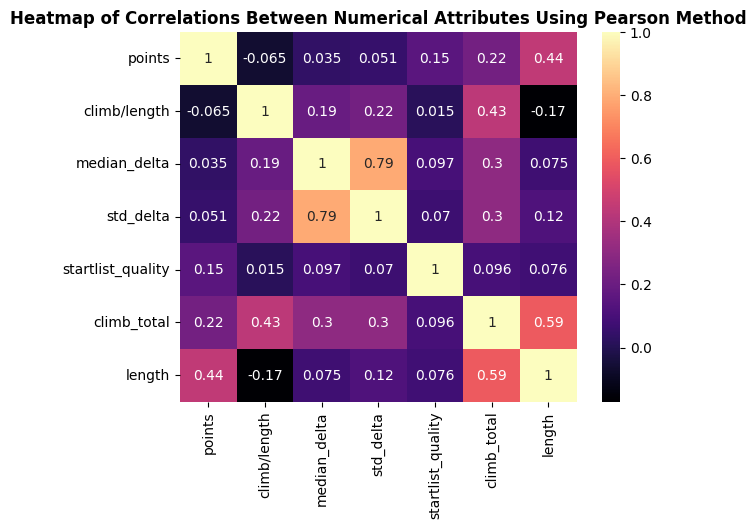

In [2448]:
pearson_matrix = numeric_races_df.corr(method='pearson')
display(pearson_matrix)
sbn.heatmap(pearson_matrix, annot=True, cmap="magma")
plt.title("Heatmap of Correlations Between Numerical Attributes Using Pearson Method", fontweight='bold')
plt.show()
plt.close()

Since _std\_delta_ and _median\_delta_ are highly correlated, we decide to drop _std\_delta_. Also _climb\_total_ and _length_ are moderately correlated.
Given that we already have the feature _climb/total_, we chose to drop _climb\_total_  while retaining _length_


In [2449]:
numeric_races_df = numeric_races_df.drop(['std_delta', 'climb_total'], axis=1)
numeric_races_df

,points,climb/length,median_delta,startlist_quality,length
0,100,0.006796,27.0,1241,162000
1,80,0.028444,1957.0,821,196000
2,100,0.006102,29.0,1699,128000
3,50,0.008395,53.0,804,8100
4,100,0.019404,1376.0,1551,192900
...,...,...,...,...,...
5276,80,0.009736,77.0,881,148000
5277,275,0.009700,270.0,808,273000
5278,50,0.009330,0.0,779,185000
5279,50,0.013783,209.0,1045,136400


In [2450]:
standardizer = standardize_fun(numeric_races_df)
standardized_races_df = standardizer['standardized_df']

        points  climb/length  median_delta  startlist_quality    length
0     0.171536     -0.759354     -0.332395           0.663219 -0.054293
1    -0.154268      1.508052      1.655025          -0.440839  0.446565
2     0.171536     -0.832122     -0.330335           1.867167 -0.555152
3    -0.642976     -0.591897     -0.305621          -0.485527 -2.321415
4     0.171536      0.561182      1.056740           1.478119  0.400899
...        ...           ...           ...                ...       ...
5276 -0.154268     -0.451394     -0.280907          -0.283116 -0.260529
5277  3.022329     -0.455254     -0.082165          -0.475012  1.580862
5278 -0.642976     -0.493998     -0.360198          -0.551244  0.284523
5279 -0.642976     -0.027555     -0.144980           0.147992 -0.431411
5280 -0.154268     -0.723055     -0.315919          -0.291002 -2.316996

[5281 rows x 5 columns]


## PCA
We apply Principal Component Analysis (PCA) to the standardized dataset (standardized_races_df) to reduce its dimensionality while preserving 90% of the variance. It calculates the number of principal components required to achieve this variance threshold and transforms the dataset into the PCA-reduced spac

In [2451]:
pca_instance = PCA(n_components=0.90)  # Preserve 90% of the variance
pca_std_numeric_races = pca_instance.fit_transform(standardized_races_df)

print(f"# selected principal components: {pca_instance.n_components_}")

# selected principal components: 5


In [2452]:
# pca = PCA()
# pca.fit(standardized_races_df) 

# # Compute the contribution (loadings) of each feature to each principal component
# loadings = pd.DataFrame(
#     pca.components_.T, # Transpose to align features with components
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)], # Label columns as PC1, PC2, etc.
#     index=numeric_races_df.columns # Use feature names as index
# )

# display(loadings)

# # Calculate the importance of each feature based on the first two principal components
# top_components = loadings.iloc[:, :2].abs().sum(axis=1) 
# top_variables = top_components.sort_values(ascending=False)


# print("\nFeatures sorted by contribution:")
# print(top_variables)


# selected_columns = top_variables.index.tolist()
# print(f"\nSelected columns: {selected_columns}")


## Kmeans greedy search

In [2453]:
results = kmeans_greedy_search(pca_std_numeric_races)

k: 2 -> silhouette: 0.3461259340005368, sse: 21260.93367558677
k: 3 -> silhouette: 0.34339133812636036, sse: 17483.108765232577, sse reduction: 17.77%
k: 4 -> silhouette: 0.34802340862548364, sse: 14225.318761815548, sse reduction: 18.63%
k: 5 -> silhouette: 0.38820762642685963, sse: 10517.769972730344, sse reduction: 26.06%
k: 6 -> silhouette: 0.38444388591252787, sse: 8960.77702483985, sse reduction: 14.80%
k: 7 -> silhouette: 0.3461641399830468, sse: 7446.918565065, sse reduction: 16.89%
k: 8 -> silhouette: 0.34745537428816237, sse: 6980.147600818902, sse reduction: 6.27%
k: 9 -> silhouette: 0.34870873161349636, sse: 6298.868477142688, sse reduction: 9.76%
k: 10 -> silhouette: 0.3417829264192173, sse: 5692.870873012619, sse reduction: 9.62%
k: 11 -> silhouette: 0.3231549484585064, sse: 5415.56175627743, sse reduction: 4.87%
k: 12 -> silhouette: 0.2861719360395804, sse: 4871.758427613646, sse reduction: 10.04%
k: 13 -> silhouette: 0.26481750894265293, sse: 4608.043166950458, sse redu

[{'k': 2, 'sse': 21260.93367558677, 'silhouette': np.float64(0.3461259340005368)}, {'k': 3, 'sse': 17483.108765232577, 'silhouette': np.float64(0.34339133812636036)}, {'k': 4, 'sse': 14225.318761815548, 'silhouette': np.float64(0.34802340862548364)}, {'k': 5, 'sse': 10517.769972730344, 'silhouette': np.float64(0.38820762642685963)}, {'k': 6, 'sse': 8960.77702483985, 'silhouette': np.float64(0.38444388591252787)}, {'k': 7, 'sse': 7446.918565065, 'silhouette': np.float64(0.3461641399830468)}, {'k': 8, 'sse': 6980.147600818902, 'silhouette': np.float64(0.34745537428816237)}, {'k': 9, 'sse': 6298.868477142688, 'silhouette': np.float64(0.34870873161349636)}, {'k': 10, 'sse': 5692.870873012619, 'silhouette': np.float64(0.3417829264192173)}, {'k': 11, 'sse': 5415.56175627743, 'silhouette': np.float64(0.3231549484585064)}, {'k': 12, 'sse': 4871.758427613646, 'silhouette': np.float64(0.2861719360395804)}, {'k': 13, 'sse': 4608.043166950458, 'silhouette': np.float64(0.26481750894265293)}, {'k': 

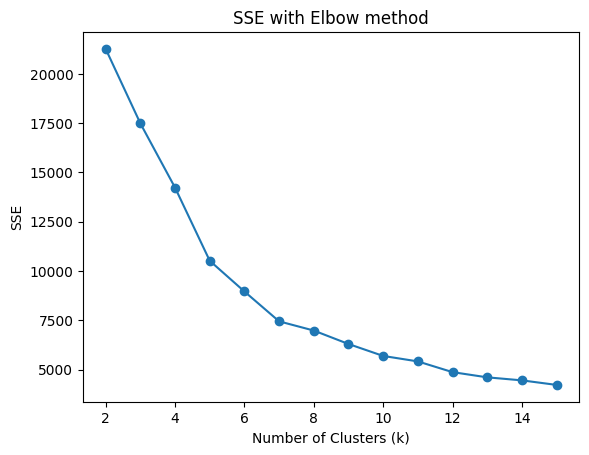

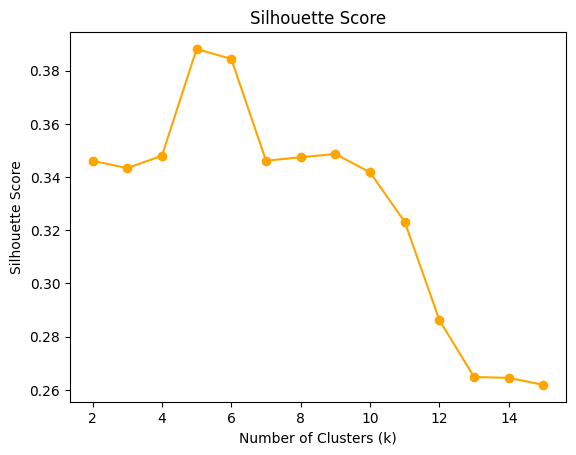

In [2454]:
k_means_evaluation_plotting(results)

## Compute Kmeans algorithm with best K found
Analyzing the Elbow Method of SSE and the Silhouette Score, the optimal  k  values do not align. The Silhouette Score suggests  k = 5  as the optimal number of clusters, while the SSE indicates  k = 6  or  k = 7 . As a trade-off, we choose  k = 6 .

In [2455]:
kmeans_data = kmeans_run(data=pca_std_numeric_races, best_k=6, scaler=standardizer['scaler'])
best_kmeans = kmeans_data['best_kmeans']
centroids = kmeans_data['centroids']


Best k based on a trade-off between silhuoette score and sse: 6
k: 6, Number of iterations: 20
Centroids
[[6.45634424e+01 1.22290993e-02 2.09023354e+02 8.23977197e+02
  1.83099257e+05]
 [7.60460993e+01 3.00357664e-02 1.15388830e+03 1.09035106e+03
  1.46040585e+05]
 [1.28333333e+02 1.80973576e-02 3.49143333e+04 8.95000000e+02
  1.97866667e+05]
 [6.14460227e+01 1.20127561e-02 1.12387074e+02 8.72784091e+02
  3.21285369e+04]
 [2.63163065e+02 1.23034037e-02 3.08014735e+02 9.21041257e+02
  2.47955678e+05]
 [9.77749361e+01 1.17806957e-02 3.67618286e+02 1.63688747e+03
  1.85870205e+05]]


In [2456]:
# count points for each cluster
cluster_counts = pd.Series(best_kmeans.labels_).value_counts().sort_index()

print("Number of points for each cluster")
print(cluster_counts)

Number of points for each cluster
0    2721
1     563
2       3
3     704
4     509
5     781
Name: count, dtype: int64


In [2457]:
# Add Cluster as a column to the dataset
numeric_races_df['Cluster'] = best_kmeans.labels_

cluster_stats = numeric_races_df.groupby('Cluster').agg('mean')

display(cluster_stats)


,points,climb/length,median_delta,startlist_quality,length
Cluster,,,,,
0,64.552738,0.012236,209.617604,823.958471,183088.673282
1,76.181172,0.030063,1153.365897,1092.735346,145863.214920
2,128.333333,0.018097,34914.333333,895.000000,197866.666667
3,61.446023,0.012013,112.387074,872.784091,32128.536932
4,263.163065,0.012303,308.014735,921.041257,247955.677800
5,97.772087,0.011760,367.337388,1636.615877,185991.037132


## Distribution of points for each feature across clusters

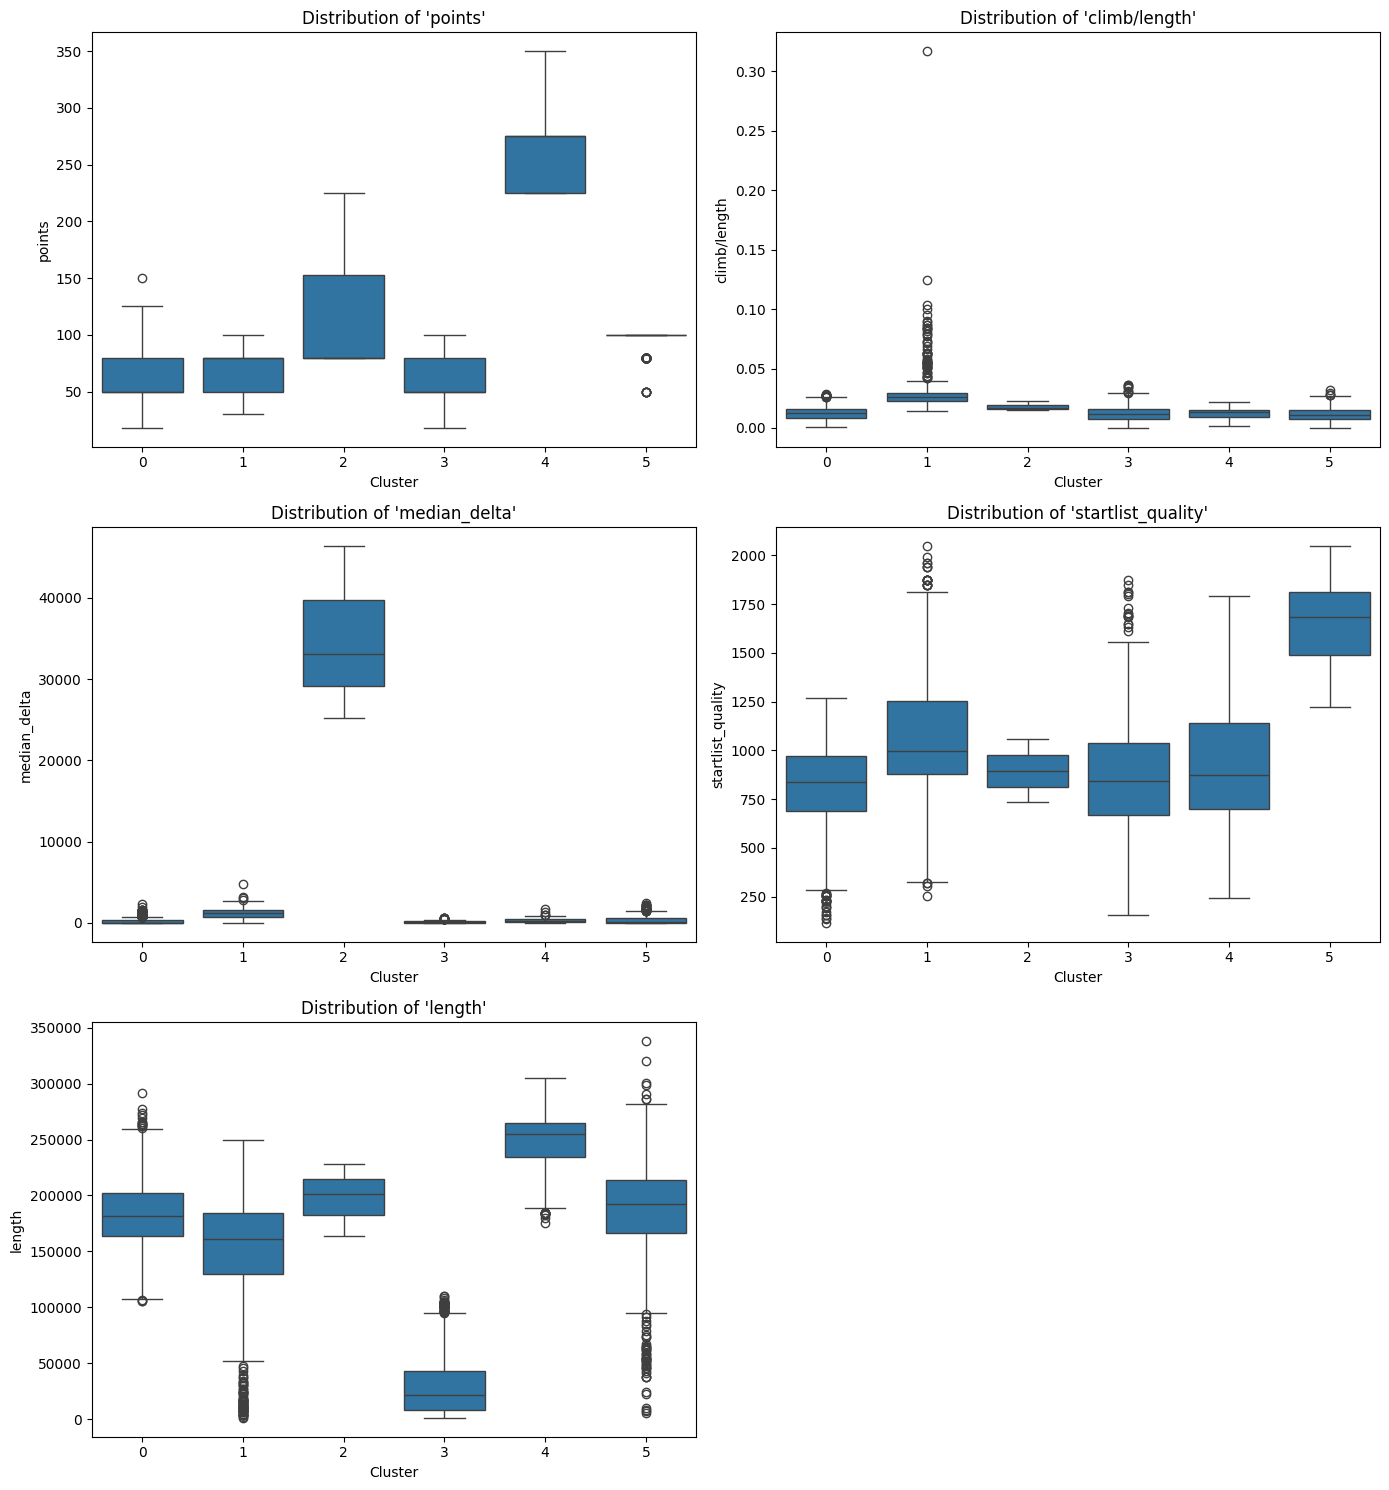

In [2458]:
clusters_box_plot(numeric_races_df)

## Clusters visualization with feature distributions and centroids 

/var/folders/1q/jqwvs2vs3kg6cxqgnbgg29q40000gn/T/ipykernel_89772/3208931329.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


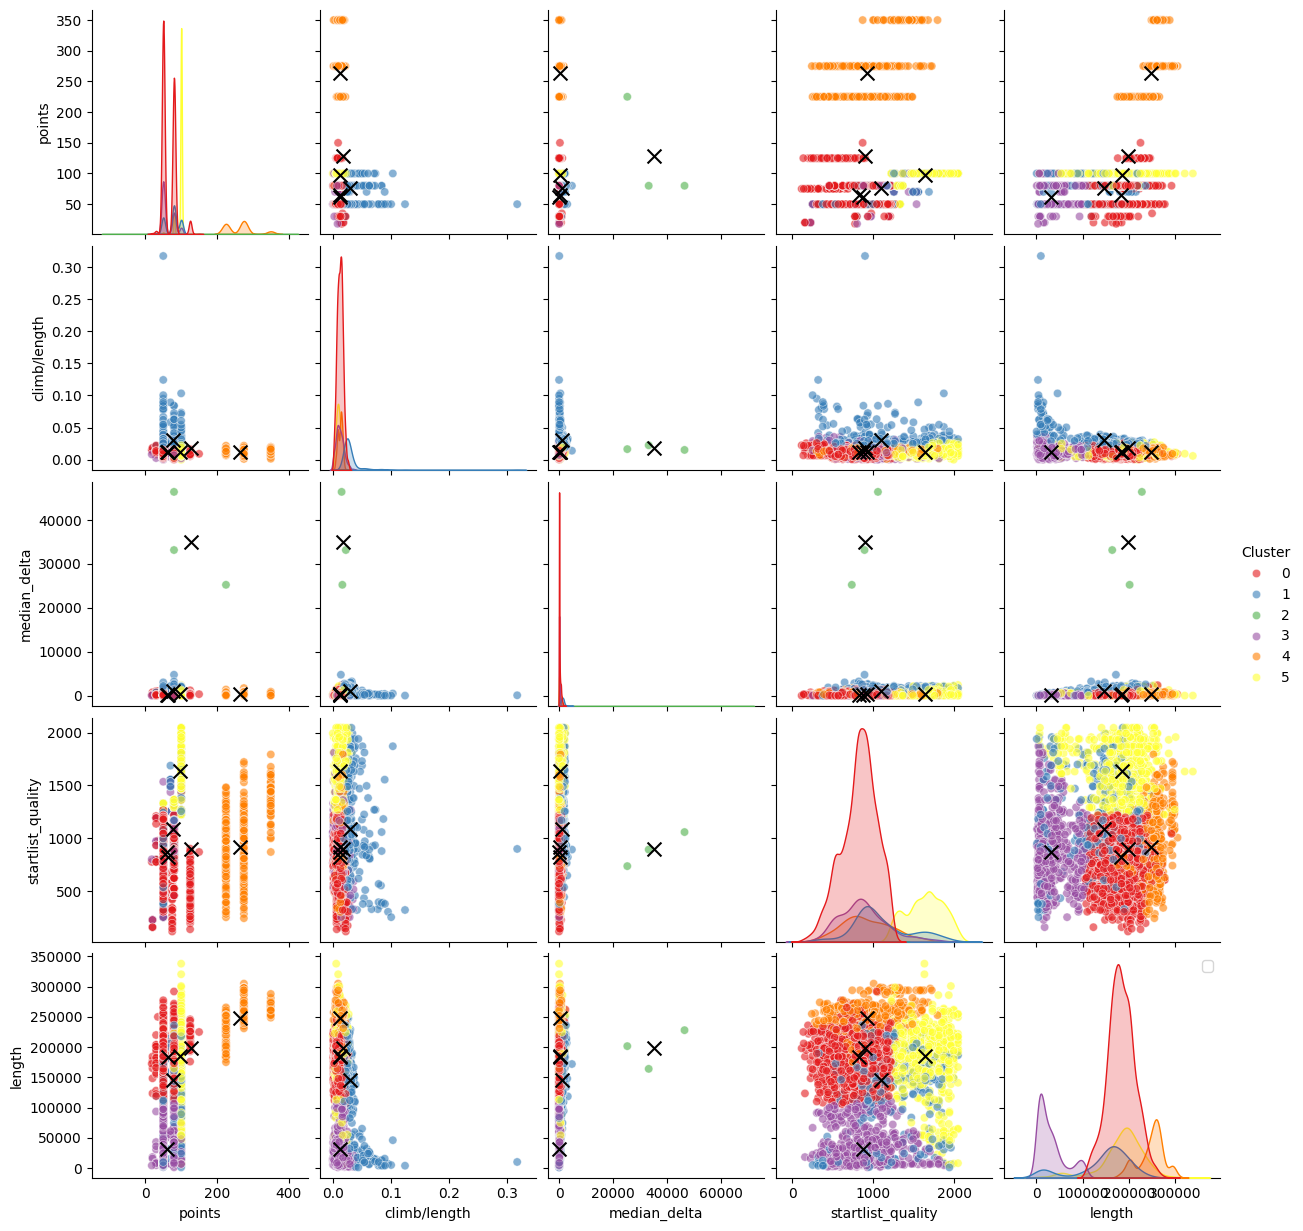

In [2459]:
clusters_pairplot(numeric_races_df, best_kmeans.labels_, centroids)